# CardioIA — IR ALÉM 2

## Inteligência Artificial em séries temporais de saúde

Este notebook compara dois métodos para classificação de séries temporais de batimentos cardíacos:

1. **Regressão Logística tradicional**, usando features estatísticas da janela temporal.
2. **Modelo neuromórfico simples inspirado em neurônios LIF**, que converte o sinal de BPM em padrões de spikes e depois usa um classificador de leitura.

O objetivo é avaliar, de forma didática, vantagens e limitações de cada abordagem para sinais vitais simulados.

In [10]:
import sys
from pathlib import Path

# Pega a pasta atual de execução do notebook
CURRENT_DIR = Path.cwd().resolve()

# Procura automaticamente a raiz do projeto CardioAI
PROJECT_ROOT = None

for base in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (base / "src" / "ir_alem_fase03" / "src" / "ir_alem_2_series_temporais" / "lif_model.py").exists():
        PROJECT_ROOT = base
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Não encontrei o lif_model.py na estrutura esperada.")

# Caminho onde está o pacote Python do Ir Além 2
IR_ALEM_SRC = PROJECT_ROOT / "src" / "ir_alem_fase03" / "src"

# Adiciona ao sys.path
if str(IR_ALEM_SRC) not in sys.path:
    sys.path.insert(0, str(IR_ALEM_SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IR_ALEM_SRC:", IR_ALEM_SRC)

PROJECT_ROOT: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI
IR_ALEM_SRC: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\src\ir_alem_fase03\src


In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from ir_alem_2_series_temporais.lif_model import LIFSpikeEncoder
# Permite importar módulos do repositório quando o notebook roda a partir da raiz do projeto
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))



RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Geração de dataset sintético

Como o foco da atividade é demonstrar a técnica, vamos criar séries temporais simuladas de BPM com três classes:

- **NORMAL:** batimentos em faixa regular.
- **TAQUICARDIA:** BPM elevado e sustentado.
- **IRREGULAR:** série com variações abruptas e picos.

In [13]:
def generate_bpm_window(label: str, length: int = 60) -> np.ndarray:
    t = np.arange(length)

    if label == "NORMAL":
        base = rng.normal(78, 5)
        signal = base + 3 * np.sin(2 * np.pi * t / 30) + rng.normal(0, 2, length)

    elif label == "TAQUICARDIA":
        base = rng.normal(132, 8)
        signal = base + 4 * np.sin(2 * np.pi * t / 20) + rng.normal(0, 3, length)

    elif label == "IRREGULAR":
        base = rng.normal(95, 10)
        signal = base + rng.normal(0, 12, length)
        spike_positions = rng.choice(length, size=5, replace=False)
        signal[spike_positions] += rng.normal(35, 8, size=5)

    else:
        raise ValueError(f"Classe desconhecida: {label}")

    return np.clip(signal, 40, 180)

labels = ["NORMAL", "TAQUICARDIA", "IRREGULAR"]
X = []
y = []

for label in labels:
    for _ in range(180):
        X.append(generate_bpm_window(label))
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Distribuição:")
print(pd.Series(y).value_counts())

Shape X: (540, 60)
Distribuição:
NORMAL         180
TAQUICARDIA    180
IRREGULAR      180
Name: count, dtype: int64


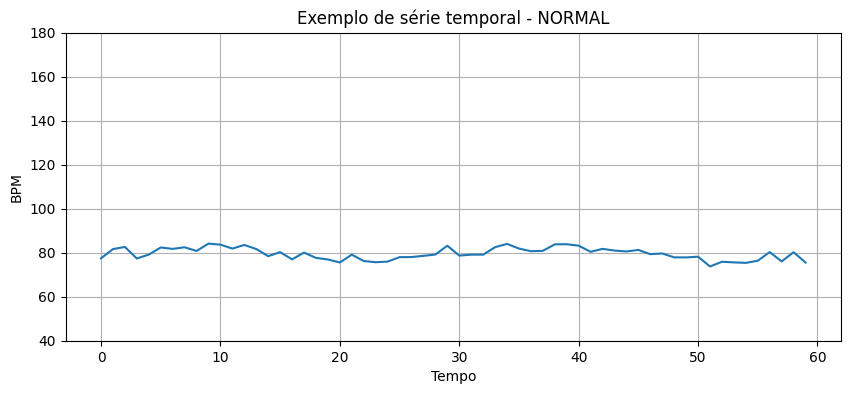

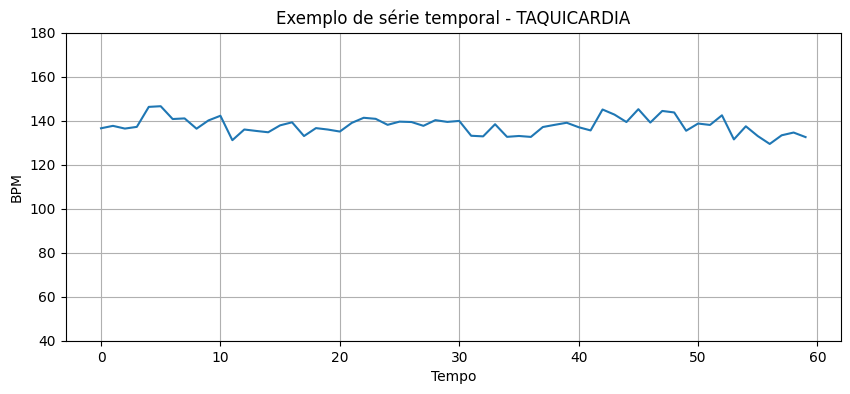

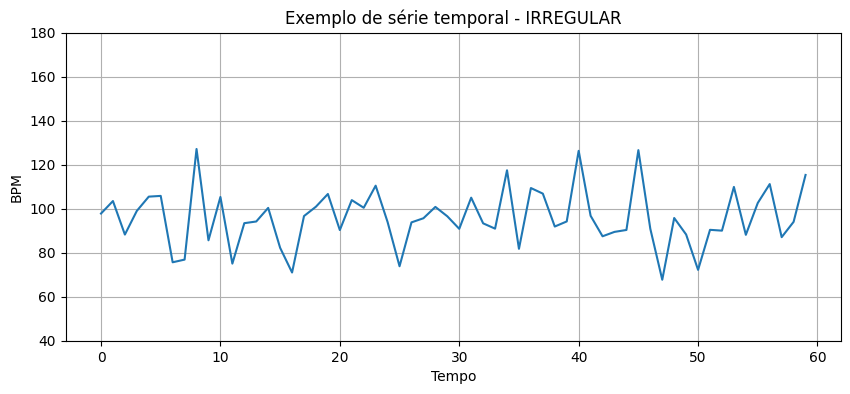

In [14]:
# Visualização de exemplos
for label in labels:
    idx = np.where(y == label)[0][0]
    plt.figure(figsize=(10, 4))
    plt.plot(X[idx])
    plt.title(f"Exemplo de série temporal - {label}")
    plt.xlabel("Tempo")
    plt.ylabel("BPM")
    plt.ylim(40, 180)
    plt.grid(True)
    plt.show()

## 2. Classificador tradicional: Regressão Logística

A abordagem tradicional transforma a série temporal em features estatísticas simples, como média, desvio padrão, mínimo, máximo e inclinação.

In [15]:
def extract_statistical_features(X: np.ndarray) -> pd.DataFrame:
    features = []

    for row in X:
        slope = row[-1] - row[0]
        features.append({
            "mean": np.mean(row),
            "std": np.std(row),
            "min": np.min(row),
            "max": np.max(row),
            "median": np.median(row),
            "q25": np.quantile(row, 0.25),
            "q75": np.quantile(row, 0.75),
            "range": np.max(row) - np.min(row),
            "slope": slope,
        })

    return pd.DataFrame(features)

X_stats = extract_statistical_features(X)
X_stats.head()

,mean,std,min,max,median,q25,q75,range,slope
0,79.587903,2.676788,73.756104,84.135551,79.504122,77.606188,81.746018,10.379447,-1.909506
1,75.992514,2.492950,70.580290,81.777201,76.077598,74.149214,77.588027,11.196911,-0.590690
2,79.058956,2.908038,72.606456,86.210092,79.004688,76.907068,81.056424,13.603636,-4.163965
3,83.282075,3.353154,76.253300,90.329747,83.169186,80.254477,85.855137,14.076448,-4.415338
4,88.702655,2.948741,81.749563,96.219726,88.248757,86.502399,90.638106,14.470163,1.828461


In [16]:
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_stats, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

traditional_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

traditional_model.fit(X_train_s, y_train)
y_pred_traditional = traditional_model.predict(X_test_s)

acc_traditional = accuracy_score(y_test, y_pred_traditional)
print("Acurácia - Regressão Logística tradicional:", round(acc_traditional, 4))
print(classification_report(y_test, y_pred_traditional))

Acurácia - Regressão Logística tradicional: 1.0
              precision    recall  f1-score   support

   IRREGULAR       1.00      1.00      1.00        45
      NORMAL       1.00      1.00      1.00        45
 TAQUICARDIA       1.00      1.00      1.00        45

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



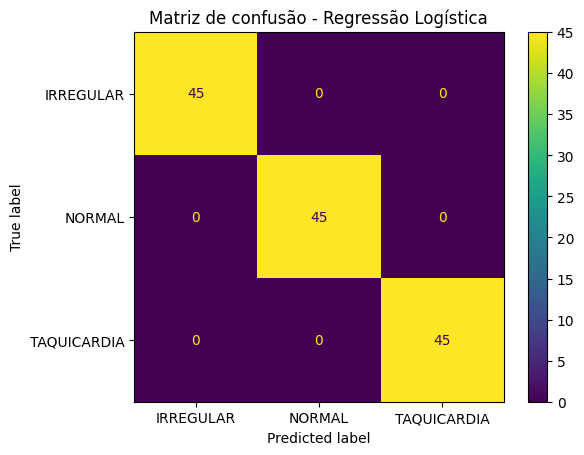

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_traditional)
plt.title("Matriz de confusão - Regressão Logística")
plt.show()

## 3. Modelo neuromórfico simples: LIF

Nesta etapa, cada janela de BPM é enviada para neurônios LIF com diferentes limiares. O sinal acumulado gera spikes quando a tensão simulada ultrapassa o limiar. A contagem e o padrão desses spikes viram features para classificação.

Esta é uma versão simplificada e acadêmica de uma abordagem neuromórfica. Ela não substitui uma implementação real em hardware neuromórfico, mas demonstra o conceito de representar sinais temporais por eventos discretos.

In [18]:
encoder = LIFSpikeEncoder(
    thresholds=[0.70, 0.95, 1.20, 1.45],
    decay=0.88,
    input_gain=1.0,
)

X_lif = encoder.transform(X)
print("Shape das features LIF:", X_lif.shape)

X_train_lif, X_test_lif, y_train_lif, y_test_lif = train_test_split(
    X_lif, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

lif_model = Pipeline([
    ("scaler", StandardScaler()),
    ("readout", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

lif_model.fit(X_train_lif, y_train_lif)
y_pred_lif = lif_model.predict(X_test_lif)

acc_lif = accuracy_score(y_test_lif, y_pred_lif)
print("Acurácia - Modelo LIF + readout:", round(acc_lif, 4))
print(classification_report(y_test_lif, y_pred_lif))

Shape das features LIF: (540, 20)
Acurácia - Modelo LIF + readout: 0.9556
              precision    recall  f1-score   support

   IRREGULAR       0.88      1.00      0.94        45
      NORMAL       1.00      0.91      0.95        45
 TAQUICARDIA       1.00      0.96      0.98        45

    accuracy                           0.96       135
   macro avg       0.96      0.96      0.96       135
weighted avg       0.96      0.96      0.96       135



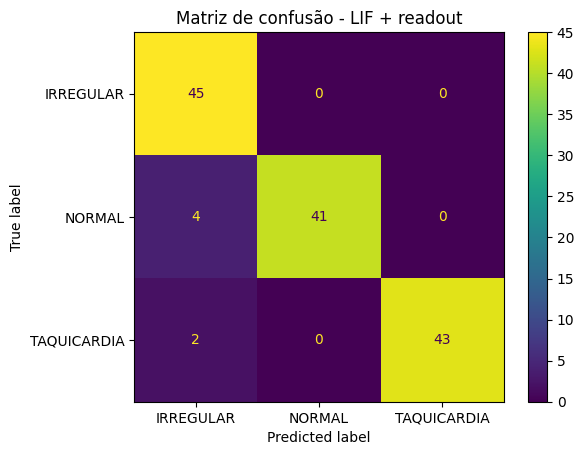

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test_lif, y_pred_lif)
plt.title("Matriz de confusão - LIF + readout")
plt.show()

## 4. Comparação final

A comparação abaixo resume o desempenho dos dois métodos. Em um cenário real, a decisão entre abordagens deve considerar desempenho, custo computacional, interpretabilidade, consumo de energia e facilidade de implantação em dispositivos de borda.

In [20]:
comparison = pd.DataFrame({
    "modelo": ["Regressão Logística tradicional", "LIF neuromórfico simples + readout"],
    "acuracia": [acc_traditional, acc_lif],
})
comparison

,modelo,acuracia
0,Regressão Logística tradicional,1.000000
1,LIF neuromórfico simples + readout,0.955556


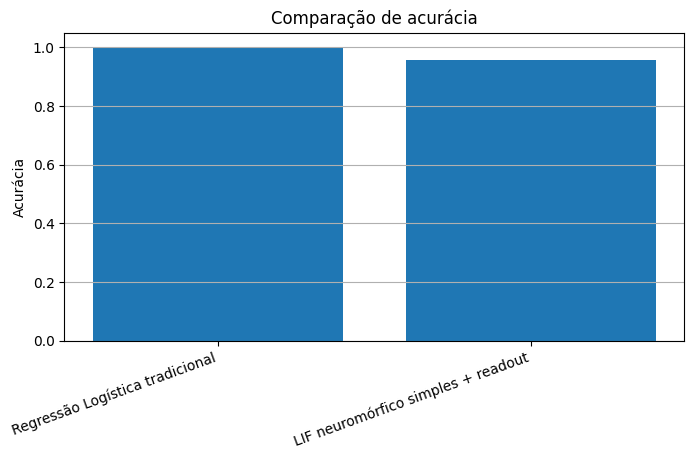

In [21]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["modelo"], comparison["acuracia"])
plt.title("Comparação de acurácia")
plt.ylabel("Acurácia")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.show()

## 5. Conclusão técnica

A Regressão Logística tradicional é simples, rápida e interpretável, especialmente quando usamos features estatísticas bem escolhidas. Ela é adequada para uma primeira versão do CardioIA por ser fácil de explicar e reproduzir.

O modelo LIF representa a série temporal por spikes, aproximando o raciocínio de redes neuromórficas. Sua vantagem conceitual está no potencial de processamento orientado a eventos, que pode ser eficiente em cenários de baixo consumo energético. A limitação é que o desempenho depende da escolha dos limiares, do decaimento e da forma de codificação do sinal.

Para uma evolução real do projeto, o próximo passo seria testar dados reais de sensores ou datasets públicos de ECG/PPG, comparar modelos com validação cruzada e avaliar latência em dispositivo de borda.